# English → Russian Seq2Seq Inference & Evaluation

This notebook loads a saved Seq2Seq model (`best_seq2seq.pt`), translates sentences, computes BLEU from scratch, and compares greedy decoding with beam search.

In [1]:
import os
import re
import math
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
checkpoint = torch.load("best_seq2seq.pt", map_location=device)

src_stoi = checkpoint["src_stoi"]
tgt_stoi = checkpoint["tgt_stoi"]
src_itos = checkpoint["src_itos"]
tgt_itos = checkpoint["tgt_itos"]

config = checkpoint["config"]

EMBED_DIM = config["EMBED_DIM"]
HIDDEN_DIM = config["HIDDEN_DIM"]
NUM_LAYERS = config["NUM_LAYERS"]

print("Checkpoint loaded.")
print("SRC vocab:", len(src_itos), "TGT vocab:", len(tgt_itos))

Checkpoint loaded.
SRC vocab: 15701 TGT vocab: 53017


In [4]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

SOS_IDX = tgt_stoi[SOS_TOKEN]
EOS_IDX = tgt_stoi[EOS_TOKEN]

In [5]:
def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^\w\s]", " ", s, flags=re.UNICODE)
    s = re.sub(r"\d+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenize(s: str):
    return clean_text(s).split()

In [6]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        _, (hidden, cell) = self.lstm(embedded)
        return hidden, cell

In [7]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        # IMPORTANT: must match the name used during training
        self.fc_out = nn.Linear(hid_dim, output_dim)

    def forward(self, input_token, hidden, cell):
        input_token = input_token.unsqueeze(1)
        embedded = self.embedding(input_token)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, cell

In [8]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

In [9]:
INPUT_DIM = len(src_itos)
OUTPUT_DIM = len(tgt_itos)

encoder = Encoder(INPUT_DIM, EMBED_DIM, HIDDEN_DIM)
decoder = Decoder(OUTPUT_DIM, EMBED_DIM, HIDDEN_DIM)
model = Seq2Seq(encoder, decoder).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [10]:
def translate(model, sentence, max_len=50):
    model.eval()
    tokens = tokenize(sentence)
    if len(tokens) == 0:
        return ""

    src_idx = [src_stoi.get(t, src_stoi[UNK_TOKEN]) for t in tokens]
    src_tensor = torch.tensor(src_idx, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)
        input_token = torch.tensor([SOS_IDX], dtype=torch.long).to(device)
        result = []

        for _ in range(max_len):
            output, hidden, cell = model.decoder(input_token, hidden, cell)
            pred_token = output.argmax(1).item()

            if pred_token == EOS_IDX:
                break

            result.append(tgt_itos[pred_token])
            input_token = torch.tensor([pred_token], dtype=torch.long).to(device)

    return " ".join(result)

In [11]:
def beam_search(model, sentence, beam_width=3, max_len=50):
    model.eval()
    tokens = tokenize(sentence)
    if len(tokens) == 0:
        return ""

    src_idx = [src_stoi.get(t, src_stoi[UNK_TOKEN]) for t in tokens]
    src_tensor = torch.tensor(src_idx, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)
        beams = [([SOS_IDX], 0.0, hidden, cell)]

        for _ in range(max_len):
            new_beams = []

            for seq, score, h, c in beams:
                input_token = torch.tensor([seq[-1]], dtype=torch.long).to(device)
                output, h_new, c_new = model.decoder(input_token, h, c)
                log_probs = F.log_softmax(output, dim=1)
                topk_probs, topk_idx = log_probs.topk(beam_width)

                for i in range(beam_width):
                    next_token = topk_idx[0][i].item()
                    new_score = score + topk_probs[0][i].item()
                    new_seq = seq + [next_token]
                    new_beams.append((new_seq, new_score, h_new, c_new))

            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]

        best_seq = beams[0][0]

        result = []
        for idx in best_seq[1:]:
            if idx == EOS_IDX:
                break
            result.append(tgt_itos[idx])

    return " ".join(result)

In [12]:
def get_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def clipped_precision(reference, hypothesis, n):
    ref_counts = Counter(get_ngrams(reference, n))
    hyp_counts = Counter(get_ngrams(hypothesis, n))

    clipped = 0
    total = 0
    for ng in hyp_counts:
        clipped += min(hyp_counts[ng], ref_counts.get(ng, 0))
        total += hyp_counts[ng]

    return 0 if total == 0 else clipped / total

def brevity_penalty(reference, hypothesis):
    r = len(reference)
    c = len(hypothesis)
    if c == 0:
        return 0
    if c > r:
        return 1
    return math.exp(1 - r / c)

def bleu_score(reference, hypothesis, max_n=4):
    weights = [1 / max_n] * max_n
    log_sum = 0.0

    for i in range(1, max_n + 1):
        p = clipped_precision(reference, hypothesis, i)
        if p == 0:
            return 0.0
        log_sum += weights[i - 1] * math.log(p)

    bp = brevity_penalty(reference, hypothesis)
    return bp * math.exp(log_sum)

In [13]:
def load_pairs_from_rus_txt(path="rus.txt"):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found in the current folder.")

    pairs = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("	")
            if len(parts) < 2:
                continue

            en, ru = parts[0].strip(), parts[1].strip()
            en_tokens = tokenize(en)
            ru_tokens = tokenize(ru)

            if en_tokens and ru_tokens:
                # add SOS/EOS to target side for reference handling
                pairs.append((en_tokens, [SOS_TOKEN] + ru_tokens + [EOS_TOKEN]))
    return pairs

pairs = load_pairs_from_rus_txt("rus.txt")
random.shuffle(pairs)

split_idx = int(0.9 * len(pairs))
train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]

print("Loaded pairs:", len(pairs))
print("Validation pairs:", len(val_pairs))
print("Example:", val_pairs[0] if val_pairs else "No validation pairs found")

Loaded pairs: 363386
Validation pairs: 36339
Example: (['i', 'said', 'that', 'as', 'a', 'joke'], ['<sos>', 'я', 'сказал', 'это', 'в', 'шутку', '<eos>'])


In [14]:
def evaluate_bleu(model, val_pairs, num_samples=100, beam_width=5):
    greedy_scores = []
    beam_scores = []

    n = min(num_samples, len(val_pairs))
    for i in range(n):
        en_tokens, ru_tokens = val_pairs[i]
        sentence = " ".join(en_tokens)
        reference = ru_tokens[1:-1]  # remove <sos> and <eos>

        greedy = translate(model, sentence).split()
        beam = beam_search(model, sentence, beam_width=beam_width).split()

        greedy_scores.append(bleu_score(reference, greedy))
        beam_scores.append(bleu_score(reference, beam))

    greedy_avg = sum(greedy_scores) / len(greedy_scores) if greedy_scores else 0.0
    beam_avg = sum(beam_scores) / len(beam_scores) if beam_scores else 0.0
    return greedy_avg, beam_avg, greedy_scores, beam_scores

greedy_bleu, beam_bleu, greedy_scores, beam_scores = evaluate_bleu(model, val_pairs, num_samples=100, beam_width=5)
print("Greedy BLEU:", greedy_bleu)
print("Beam BLEU   :", beam_bleu)

Greedy BLEU: 0.09094622395030841
Beam BLEU   : 0.1259919649616753


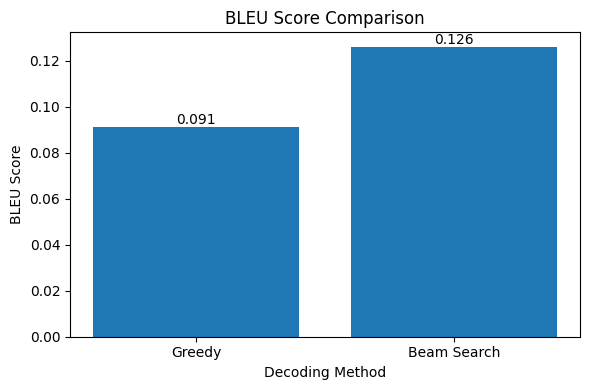

In [18]:
methods = ["Greedy", "Beam Search"]
scores = [greedy_bleu, beam_bleu]

plt.figure(figsize=(6, 4))
bars = plt.bar(methods, scores)
plt.xlabel("Decoding Method")
plt.ylabel("BLEU Score")
plt.title("BLEU Score Comparison")

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{score:.3f}",
             ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [20]:
samples = [
    "hello",
    "how are you",
    "good morning",
    "i love you",
    "what is your name"
]

for s in samples:
    print("EN :", s)
    print("Greedy:", translate(model, s))
    print("Beam  :", beam_search(model, s, beam_width=5))


EN : hello
Greedy: птицы
Beam  : у себя
EN : how are you
Greedy: как ты
Beam  : как ты
EN : good morning
Greedy: сегодня утром
Beam  : всё утро
EN : i love you
Greedy: я люблю вас
Beam  : я тебя люблю
EN : what is your name
Greedy: как зовут
Beam  : ваше имя


In [21]:
for i in range(min(5, len(val_pairs))):
    en_tokens, ru_tokens = val_pairs[i]
    en_sentence = " ".join(en_tokens)
    reference = " ".join(ru_tokens[1:-1])

    greedy_out = translate(model, en_sentence)
    beam_out = beam_search(model, en_sentence, beam_width=5)

    print("EN     :", en_sentence)
    print("REF    :", reference)
    print("GREEDY :", greedy_out)
    print("BEAM   :", beam_out)

EN     : i said that as a joke
REF    : я сказал это в шутку
GREEDY : я сказал это шутку
BEAM   : я сказал это это шутка
EN     : i saw tom in boston
REF    : я видел в бостоне тома
GREEDY : я видел тома в бостоне
BEAM   : я видела тома в бостоне
EN     : i m cautiously optimistic
REF    : я смотрю с осторожным оптимизмом
GREEDY : я закончил
BEAM   : я закончил
EN     : who did tom think was going to win the race
REF    : кто как считал том выиграет гонку
GREEDY : кто том подумал что том победит
BEAM   : кто думал что том победит
EN     : he ran so fast that i couldn t catch up with him
REF    : он бежал так быстро что я не поспевала за ним
GREEDY : он бежал быстро поэтому я не смог бы с ним
BEAM   : он бежал так быстро что я не смог его с ним
